# Using Python to Verify AI

In [1]:
# Import Packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns

In [2]:
# Create timestamp and author
from datetime import datetime 
time_now=datetime.now().strftime('%m_%d_%Y_%I%M%p')
print("Current Time:{}".format(time_now))
print("Tina Pham")

Current Time:09_26_2026_0323PM
Tina Pham


In [4]:
# Read the dataset and store it as data2026
data2026=pd.read_csv('2026PartYear.csv',encoding='utf-8')
data2025 = pd.read_csv('2025.csv', encoding='utf-8')

In [28]:
# Safely filter 2025 data to Periods 1-8 / Weeks 1-32
if "Week" in data2025.columns: data2025 = data2025[data2025["Week"].astype(str).str.extract(r"(\d+)")[0].astype(int) <= 32].copy()
elif "Period" in data2025.columns:
    data2025 = data2025[data2025["Period"] <= 8].copy()
elif "Date" in data2025.columns:
    data2025["Date"] = pd.to_datetime(data2025["Date"])
    data2025_filtered = data2025[data2025["Date"].dt.isocalendar().week <= 32].copy()

In [26]:
# Calculate Revenue
data2025["Revenue"] = (data2025["ASP Current Year"]* data2025["Total Bulk and Bags"])
data2026["Revenue"] = (data2026["ASP Current Year"] * data2026["Total Bulk and Bags"])

# Overall YoY Market Performance

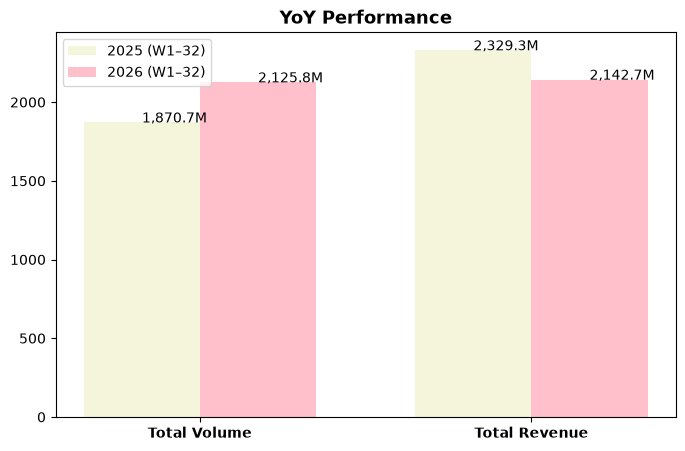

In [74]:
fig, ax1 = plt.subplots(figsize=(8, 5))
categories = ["Total Volume", "Total Revenue"]
x = np.arange(len(categories))
width = 0.35

vals_2025 = [1870.70, 2329.30]
vals_2026 = [2125.80, 2142.66]

rects1 = ax1.bar( x - width / 2, vals_2025, width, label="2025 (W1–32)", color="Beige")
rects2 = ax1.bar( x + width / 2, vals_2026, width, label="2026 (W1–32)", color="Pink")

ax1.set_title("YoY Performance", fontsize=13, fontweight="bold")

ax1.set_xticks(x)
ax1.set_xticklabels(categories, fontweight="bold")
ax1.legend()

for p in ax1.patches:
    h = p.get_height()
    if h > 0:
        ax1.annotate(f"{h:,.1f}M",(p.get_x() + p.get_width() / 2.0, h))

plt.show()

# Product Type Breakdown

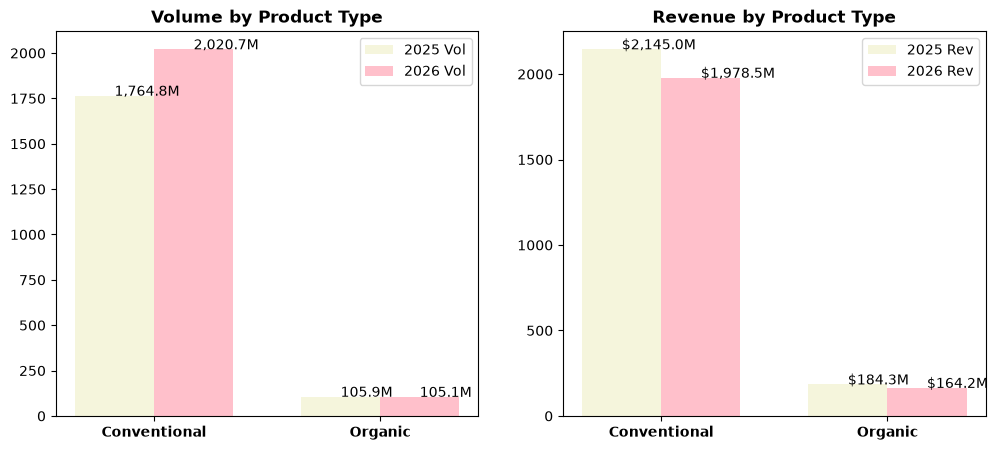

In [71]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
types = ["Conventional", "Organic"]
vol_2025, vol_2026 = [1764.84, 105.86], [2020.68, 105.12]
rev_2025, rev_2026 = [2145.04, 184.27], [1978.50, 164.16]
x = np.arange(len(types))

# Volume Plot
ax1.bar(x - width / 2, vol_2025, width, label="2025 Vol", color="Beige")
ax1.bar(x + width / 2, vol_2026, width, label="2026 Vol", color="Pink")
ax1.set_title("Volume by Product Type", fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(types, fontweight="bold")
ax1.legend()

for p in ax1.patches:
    h = p.get_height()
    if h > 0:
        ax1.annotate(f"{h:,.1f}M", (p.get_x() + p.get_width() / 2.0, h))

# Revenue Plot
ax2.bar(x - width / 2, rev_2025, width, label="2025 Rev", color="Beige")
ax2.bar(x + width / 2, rev_2026, width, label="2026 Rev", color="Pink")
ax2.set_title("Revenue by Product Type", fontweight="bold")
ax2.set_xticks(x)
ax2.set_xticklabels(types, fontweight="bold")
ax2.legend()

for p in ax2.patches:
    h = p.get_height()
    if h > 0:
        ax2.annotate(f"${h:,.1f}M", (p.get_x() + p.get_width() / 2.0, h))

plt.show()

# ASP

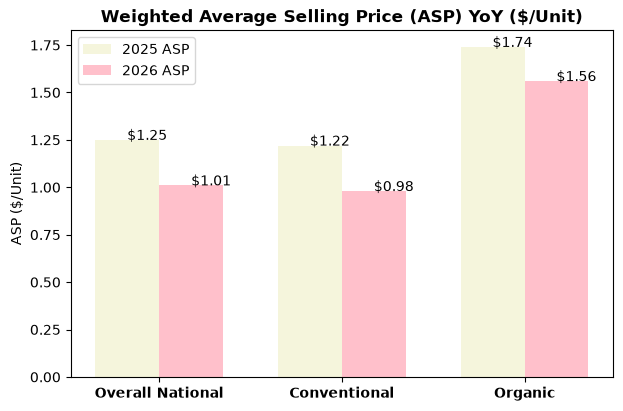

In [105]:
fig, ax = plt.subplots(figsize=(7, 4.5))
asp_2025 = [1.25, 1.22, 1.74]
asp_2026 = [1.01, 0.98, 1.56]
labels = ["Overall National", "Conventional", "Organic"]
x = np.arange(len(labels))

ax.bar(x - width / 2, asp_2025, width, label="2025 ASP", color="Beige")
ax.bar(x + width / 2, asp_2026, width, label="2026 ASP", color="Pink")

ax.set_title("Weighted Average Selling Price (ASP) YoY ($/Unit)", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontweight="bold")
ax.set_ylabel("ASP ($/Unit)")
ax.legend()

for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"${h:.2f}", (p.get_x() + p.get_width() / 2.0, h))

plt.show()

# Regional 

In [90]:
# Filter specifically for the regions and metro areas 
regions = ['Southeast', 'California', 'West', 'Northeast', 'Midsouth', 'Philadelphia', 'Harrisburg/Scranton']

In [78]:
regional_summary = (new.groupby("Geography").agg(Total_Volume=("Total Bulk and Bags", "sum"), Total_Revenue=("Revenue", "sum"), Avg_ASP=("ASP Current Year", "mean")).reset_index().rename(columns={"Geography": "region"}))

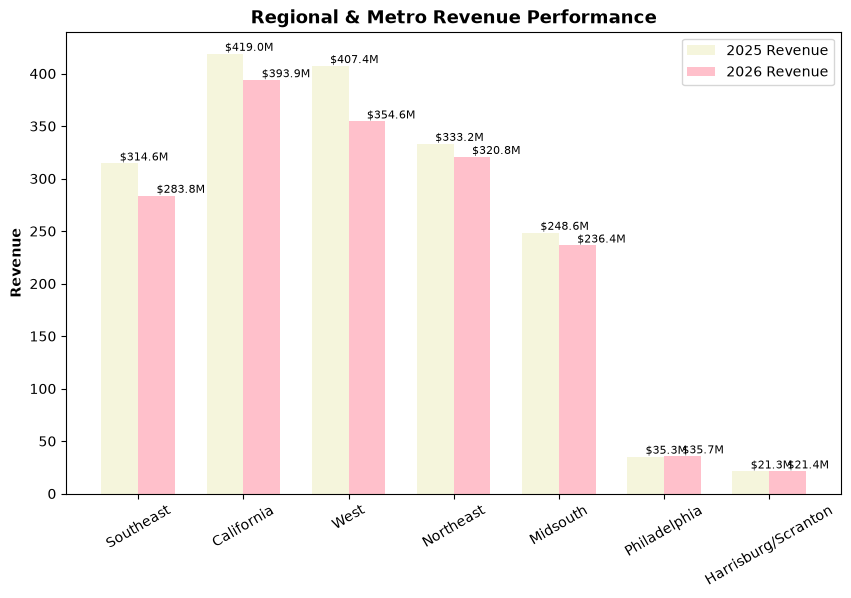

In [112]:
# Display formatted audit table
regional_audit = regional_summary[regional_summary['region'].isin(target_regions)].copy()

# Bar Chart
fig, ax2 = plt.subplots(figsize=(10, 6))

# Volume Data 
vol_2025 = [264.26, 292.61, 291.41, 282.23, 205.93, 26.24, 15.82]
vol_2026 = [316.63, 336.44, 311.73, 320.81, 236.44, 30.63, 18.39]

# Revenue Data 
rev_2025 = [314.62, 419.04, 407.39, 333.24, 248.57, 35.30, 21.27]
rev_2026 = [283.83, 393.90, 354.63, 320.81, 236.44, 35.68, 21.35]

# Weighted ASP Data 
asp_2025 = [1.19, 1.43, 1.40, 1.18, 1.21, 1.35, 1.34]
asp_2026 = [0.90, 1.17, 1.14, 1.00, 1.00, 1.16, 1.16]

x = np.arange(len(regions))
width = 0.35

# YoY Revenue Leadership & Resilience
rects3 = ax2.bar(x - width / 2, rev_2025, width, label="2025 Revenue", color="Beige")
rects4 = ax2.bar(x + width / 2, rev_2026, width, label="2026 Revenue", color="Pink")

ax2.set_title("Regional & Metro Revenue Performance", fontsize=13, fontweight="bold")
ax2.set_xticks(x)
ax2.set_xticklabels(regions, rotation=30)
ax2.set_ylabel("Revenue", fontweight="bold")
ax2.legend()

for p in ax2.patches:
    h = p.get_height()
    if h > 0:
        ax2.annotate(f"${h:,.1f}M",(p.get_x() + p.get_width() / 2.0, h), fontsize=8, xytext=(0, 2), textcoords="offset points")

plt.show()

In [113]:
new=pd.concat([data2026,data2025])
new.describe()

,Period,ASP Current Year,Total Bulk and Bags,4046,4225,4770,TotalBagged,Sml Bagged,Lrg Bagged,X-Lrg Bagged,Unknown Bag Size,Revenue
count,5120.000000,5120.000000,5.120000e+03,5.120000e+03,5.120000e+03,5.120000e+03,5.120000e+03,5.120000e+03,5.120000e+03,5.120000e+03,5.120000e+03,5.120000e+03
mean,14.100000,1.295115,1.388329e+06,5.849427e+05,1.728317e+05,2.967044e+04,6.008843e+05,4.989487e+05,6.095362e+04,1.187733e+04,2.910460e+04,1.458654e+06
std,9.607707,0.341484,5.721616e+06,2.552125e+06,7.423426e+05,1.505406e+05,2.348784e+06,1.911350e+06,2.701625e+05,6.203711e+04,1.246132e+05,5.827446e+06
min,1.000000,0.680085,3.396173e+03,0.000000e+00,0.000000e+00,0.000000e+00,2.014177e+03,2.014177e+03,0.000000e+00,0.000000e+00,0.000000e+00,4.965113e+03
25%,5.750000,1.008337,3.680098e+04,9.632867e+02,2.078912e+03,0.000000e+00,2.983570e+04,2.866173e+04,0.000000e+00,0.000000e+00,0.000000e+00,5.350058e+04
50%,12.500000,1.302811,2.196166e+05,6.259412e+04,1.900091e+04,2.031229e+01,1.113644e+05,9.617560e+04,3.922603e+03,0.000000e+00,1.359575e+03,2.575375e+05
75%,22.250000,1.504351,7.140488e+05,2.973445e+05,8.772838e+04,2.275114e+03,3.523051e+05,2.966555e+05,2.698910e+04,1.488470e+03,1.380607e+04,8.528056e+05
max,32.000000,3.024088,7.596885e+07,3.687941e+07,1.177366e+07,2.218004e+06,3.079944e+07,2.487659e+07,3.797330e+06,1.239333e+06,1.646700e+06,7.961802e+07
